In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('/kaggle/input/datasets/akshat3422/assessment/train-test.csv')

In [3]:
df.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [4]:
# Target is posted_rate 
target = df['posted_rate']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [6]:
max(df['market_index'].unique())

np.float64(1.46778)

In [7]:
df.loc[df['weight'] < 0, 'weight'] = np.nan

In [8]:
wt_missing=df.groupby('equipment', as_index=False)['weight'].mean()
df['weight'] = df['weight'].fillna(df['equipment'].map(wt_missing.set_index('equipment')['weight']))

In [9]:
##  market_index means what is the type of market, 
# A higher market_index generally means capacity is tighter / demand is stronger / market rates are higher,

## A quote_signal generally represents some signal related to the expected/quoted price for a particular load.


In [10]:
from matplotlib import pyplot as plt


<Axes: xlabel='equipment'>

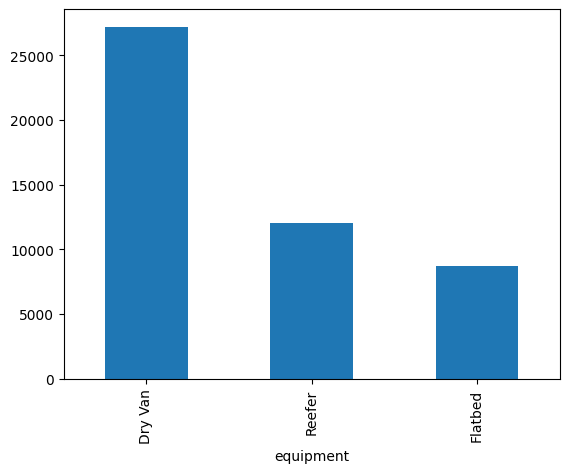

In [11]:
df['equipment'].value_counts().plot(kind='bar')

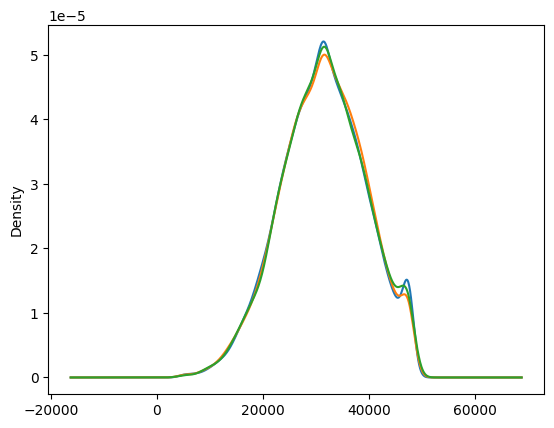

In [12]:
total_equipment = df['equipment'].value_counts().index
for equipment in total_equipment:
    df[df['equipment']==equipment]['weight'].plot(kind='kde', label=equipment)



In [13]:
(df['weight'] < 0).sum()
(df['weight'] < 0).mean() * 100

np.float64(0.0)

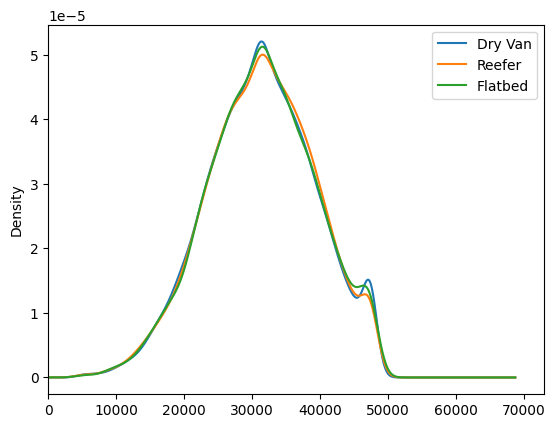

In [14]:
total_equipment = df['equipment'].value_counts().index
for equipment in total_equipment:
    df[df['equipment']==equipment]['weight'].plot(kind='kde', label=equipment)
plt.xlim(left=0)

plt.legend()
plt.show()

In [15]:
df.groupby('equipment')['weight'].agg(['count', 'mean', 'median', 'std'])

,count,mean,median,std
equipment,,,,
Dry Van,27202,31388.566798,31388.566798,7957.696272
Flatbed,8753,31475.339128,31475.339128,7939.630658
Reefer,12045,31432.359002,31467.000000,7922.331549


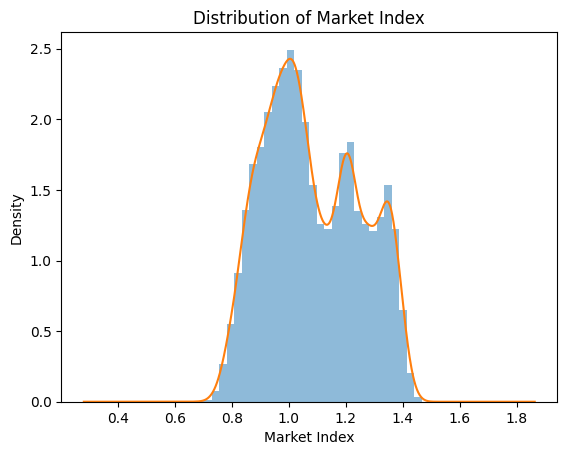

In [16]:
import matplotlib.pyplot as plt

df['market_index'].plot(
    kind='hist',
    bins=30,
    density=True,
    alpha=0.5
)

df['market_index'].plot(
    kind='kde'
)

plt.xlabel('Market Index')
plt.ylabel('Density')
plt.title('Distribution of Market Index')
plt.show()

In [17]:
print(df['market_index'].skew())

0.21426317657348584


In [18]:
df['market_index'].agg(['mean', 'median', 'std', 'min', 'max'])

mean      1.083387
median    1.055800
std       0.168091
min       0.676390
max       1.467780
Name: market_index, dtype: float64

In [19]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

<Axes: xlabel='date'>

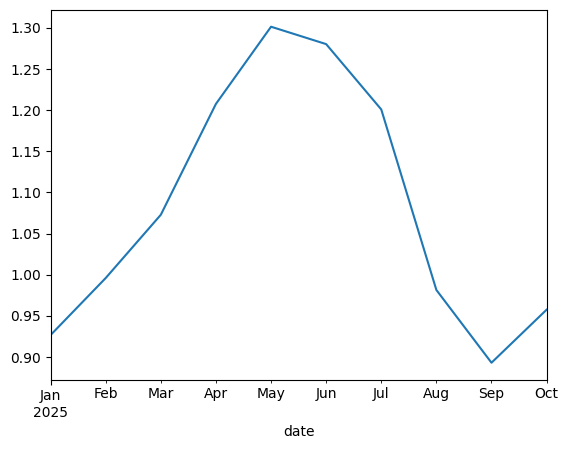

In [20]:
df.groupby(df['date'].dt.to_period('M'))['market_index'].mean().plot()

In [21]:
df.groupby(df['date'].dt.month)['market_index'].mean()

date
1     0.926696
2     0.995997
3     1.072880
4     1.207649
5     1.301452
6     1.280316
7     1.200893
8     0.981480
9     0.893039
10    0.957502
Name: market_index, dtype: float64

In [22]:
month_mean = df.groupby(df['date'].dt.month)['market_index'].transform('mean')

df['market_index'] = df['market_index'].fillna(month_mean)

In [23]:
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

In [24]:
df.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,date,market_index,quote_signal,posted_rate,month,day_of_week,is_weekend
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31415.379200,2025-05-31 19:53:29.400000,1.083427,2.062468,2373.980682,5.505312,3.003146,0.282875
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,5000.000000,2025-01-01 00:00:00,0.676390,0.692280,57.220000,1.000000,0.000000,0.000000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,26007.750000,2025-03-18 00:00:00,0.949897,1.891030,1251.555000,3.000000,1.000000,0.000000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31432.359002,2025-05-31 00:00:00,1.055865,2.055750,2030.760000,5.000000,3.000000,0.000000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,36985.000000,2025-08-15 00:00:00,1.219510,2.221685,3330.750000,8.000000,5.000000,1.000000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,2025-10-31 00:00:00,1.467780,3.610350,25533.000000,10.000000,6.000000,1.000000
std,4.315285,13.482431,4.317199,13.476589,728.564416,7945.448037,NaN,0.167928,0.291391,1486.493245,2.864084,1.990637,0.450401


In [25]:
final_df = df.drop(columns=['date', 'day_of_week'])

In [26]:
final_df=df.drop(['date','load_id'], axis=1)

In [27]:
final_df.head()

,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,market_index,quote_signal,posted_rate,month,day_of_week,is_weekend
0,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,0.95684,2.39595,645.41,1,2,0
1,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,0.97623,2.43355,679.97,1,2,0
2,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,1.00971,1.84491,1802.54,1,2,0
3,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,0.94518,1.87712,1827.28,1,2,0
4,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,0.98480,2.56300,1380.28,1,2,0


In [28]:
from sklearn.model_selection import train_test_split
X = final_df.drop(columns=['posted_rate'])
y = final_df['posted_rate']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [29]:
categorical_cols = ['equipment', 'pickup', 'delivery', 'is_weekend','month']

from catboost import CatBoostRegressor
model = CatBoostRegressor(
    iterations=500,
    depth=7,
    learning_rate=0.05,
    verbose=False
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_cols
)

CatBoostRegressor(depth=7, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=False)

In [30]:
model.score(X_test, y_test)

np.float64(0.8622347718825678)

In [31]:
from sklearn.metrics import r2_score
y_pred=model.predict(X_test)
score=r2_score(y_test, y_pred)
print(f"end=to-end R2 score: {score:.4f}")

end=to-end R2 score: 0.8622


In [32]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

print("Train MAE:", mean_absolute_error(y_train, train_pred))
print("Test MAE:", mean_absolute_error(y_test, test_pred))

print("Train RMSE:", mean_squared_error(y_train, train_pred) ** 0.5)
print("Test RMSE:", mean_squared_error(y_test, test_pred) ** 0.5)

Train R2: 0.8485348253121516
Test R2: 0.8622347718825678
Train MAE: 107.10941947064376
Test MAE: 105.00056232575194
Train RMSE: 582.3612078913479
Test RMSE: 543.07724009734


In [33]:
print(y.sort_values(ascending=False).head(20))

12184    25533.00
37764    24294.98
1466     24140.21
17371    23662.71
26235    23580.42
28219    22755.66
3353     22534.65
40171    20361.89
40096    20132.37
47298    19110.30
31259    19042.39
34583    18972.15
46213    17893.17
20245    17772.53
35468    17742.34
4657     17688.63
43539    17514.11
33074    17333.65
32352    16951.43
17763    16841.60
Name: posted_rate, dtype: float64


(array([3.0664e+04, 1.5482e+04, 1.7060e+03, 5.1000e+01, 4.7000e+01,
        2.8000e+01, 9.0000e+00, 6.0000e+00, 2.0000e+00, 5.0000e+00]),
 array([   57.22 ,  2604.798,  5152.376,  7699.954, 10247.532, 12795.11 ,
        15342.688, 17890.266, 20437.844, 22985.422, 25533.   ]),
 <BarContainer object of 10 artists>)

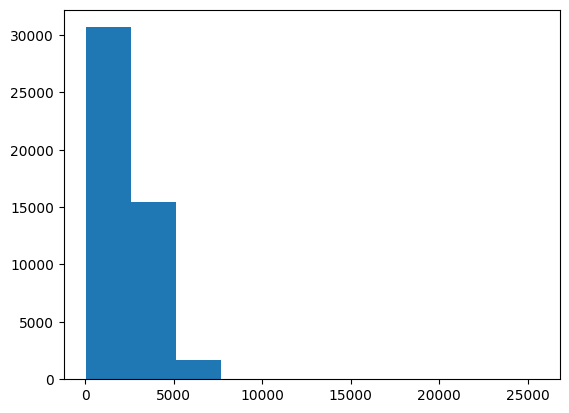

In [34]:
plt.hist(y)

In [35]:
import numpy as np

y_train_log = np.log1p(y_train)

In [36]:
model.fit(
    X_train,
    y_train_log,
    cat_features=categorical_cols
)

CatBoostRegressor(depth=7, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=False)

In [37]:
pred_log = model.predict(X_test)
pred = np.expm1(pred_log)

In [38]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", mean_squared_error(y_test, pred) ** 0.5)

R2: 0.8636741730841153
MAE: 93.06773147115274
RMSE: 540.2326956554883


In [39]:
final_df.head()

,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,market_index,quote_signal,posted_rate,month,day_of_week,is_weekend
0,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,0.95684,2.39595,645.41,1,2,0
1,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,0.97623,2.43355,679.97,1,2,0
2,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,1.00971,1.84491,1802.54,1,2,0
3,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,0.94518,1.87712,1827.28,1,2,0
4,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,0.98480,2.56300,1380.28,1,2,0


In [40]:
## dropping ciites

dc=df.drop(['pickup','delivery'], axis=1)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(dc.drop(columns=['posted_rate','load_id','date']), dc['posted_rate'], test_size=0.3, random_state=42)

In [42]:
y_train_log = np.log1p(y_train)
categorical_cols = ['equipment', 'is_weekend','month']


model.fit(
    X_train,
    y_train_log,
    cat_features=categorical_cols 
)

CatBoostRegressor(depth=7, iterations=500, learning_rate=0.05, loss_function='RMSE', verbose=False)

## Training with LightGBM

In [43]:
X_train, X_test, y_train, y_test = train_test_split(dc.drop(columns=['posted_rate','load_id','date']), dc['posted_rate'], test_size=0.3, random_state=42)

In [44]:
y_train_log = np.log1p(y_train)


In [45]:
from lightgbm import LGBMRegressor
categorical_cols = ['equipment', 'is_weekend','month']
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

for col in categorical_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')


lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(
    X_train_lgb,
    y_train_log,
    categorical_feature=categorical_cols
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002675 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1303
[LightGBM] [Info] Number of data points in the train set: 33600, number of used features: 12
[LightGBM] [Info] Start training from score 7.572863


LGBMRegressor(learning_rate=0.05, n_estimators=1000, random_state=42)

In [46]:
# LightGBM predictions
lgb_train_log = lgb_model.predict(X_train_lgb)
lgb_test_log = lgb_model.predict(X_test_lgb)

lgb_train_pred = np.expm1(lgb_train_log)
lgb_test_pred = np.expm1(lgb_test_log)

print("===== LightGBM =====")
print("Train R2:", r2_score(y_train, lgb_train_pred))
print("Test R2:", r2_score(y_test, lgb_test_pred))

print("Train MAE:", mean_absolute_error(y_train, lgb_train_pred))
print("Test MAE:", mean_absolute_error(y_test, lgb_test_pred))

print("Train RMSE:", mean_squared_error(y_train, lgb_train_pred) ** 0.5)
print("Test RMSE:", mean_squared_error(y_test, lgb_test_pred) ** 0.5)

===== LightGBM =====
Train R2: 0.8771605311788263
Test R2: 0.8596783818016398
Train MAE: 96.39941422265754
Test MAE: 115.02942120791361
Train RMSE: 524.4511088949554
Test RMSE: 548.0927868684718


In [47]:
dc = df.drop(['pickup', 'delivery'], axis=1)

dc["distance_bin"] = pd.cut(
    dc["distance"],
    bins=[0, 500, 1000, 1500, 2000, 3000, np.inf],
    labels=[
        "0-500",
        "500-1000",
        "1000-1500",
        "1500-2000",
        "2000-3000",
        "3000+"
    ]
)

dc["distance_equipment"] = (
    dc["distance_bin"].astype(str) + "_" +
    dc["equipment"].astype(str)
)

# We only need the interaction, so remove the intermediate column
dc = dc.drop(columns=["distance_bin"])

categorical_cols = [
    'equipment',
    'is_weekend',
    'month',
    'distance_equipment'
]
X = dc.drop(columns=["posted_rate", "load_id", "date"])
y = dc["posted_rate"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

y_train_log = np.log1p(y_train)

model.fit(
    X_train,
    y_train_log,
    cat_features=categorical_cols
)

cb_train_log = model.predict(X_train)
cb_test_log = model.predict(X_test)

cb_train_pred = np.expm1(cb_train_log)
cb_test_pred = np.expm1(cb_test_log)

print("===== CatBoost =====")
print("Train R2:", r2_score(y_train, cb_train_pred))
print("Test R2:", r2_score(y_test, cb_test_pred))

print("Train MAE:", mean_absolute_error(y_train, cb_train_pred))
print("Test MAE:", mean_absolute_error(y_test, cb_test_pred))

print("Train RMSE:", mean_squared_error(y_train, cb_train_pred) ** 0.5)
print("Test RMSE:", mean_squared_error(y_test, cb_test_pred) ** 0.5)

===== CatBoost =====
Train R2: 0.838560521967374
Test R2: 0.8633820335534654
Train MAE: 95.34039261574512
Test MAE: 94.2733970265225
Train RMSE: 601.2303775506749
Test RMSE: 540.8112319031313


### clearly CatBoost is performing better 

In [48]:
importance = model.get_feature_importance()

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importance
}).sort_values('importance', ascending=False)

print(feature_importance)

               feature  importance
4             distance   91.904297
5            equipment    2.539390
6               weight    1.035399
7         market_index    0.744773
8         quote_signal    0.633789
1           pickup_lon    0.588659
9                month    0.571916
3         delivery_lon    0.544946
0           pickup_lat    0.524730
2         delivery_lat    0.426546
12  distance_equipment    0.333896
10         day_of_week    0.117609
11          is_weekend    0.034049


In [49]:
import numpy as np
import pandas as pd

def engineer_features(df_input: pd.DataFrame) -> pd.DataFrame:
    dc = df_input.copy()

    # 2. Physics & Logistics Work Interactions
    dc['ton_miles'] = dc['distance'] * (dc['weight'] / 2000.0)
    # dc['weight_per_mile'] = dc['weight'] / (dc['distance'] + 1.0)
    dc['log_distance'] = np.log1p(dc['distance'])
    # dc['sqrt_distance'] = np.sqrt(dc['distance'])

    # 3. Market Signals Interactions (if present)
    if 'quote_signal' in dc.columns and 'market_index' in dc.columns:
        dc['distance_x_quote'] = dc['distance'] * dc['quote_signal']
        dc['distance_x_market'] = dc['distance'] * dc['market_index']
        # dc['market_x_quote'] = dc['market_index'] * dc['quote_signal']
        # dc['quote_per_ton'] = dc['quote_signal'] / (dc['weight'] / 2000.0 + 1.0)
        # dc['market_tightness']     = dc['market_index'] * dc['quote_signal']
        # dc['quote_market_ratio']   = dc['quote_signal'] / (dc['market_index'] + 1e-5)
        # dc['log_quote_market_ratio'] = np.log1p(dc['quote_market_ratio'])

    # 4. Geospatial / Lane Interactions (if coordinates present)
    dc['pickup_zone']   = dc['pickup_lat'].round(1).astype(str) + "_" + dc['pickup_lon'].round(1).astype(str)
    dc['delivery_zone'] = dc['delivery_lat'].round(1).astype(str) + "_" + dc['delivery_lon'].round(1).astype(str)
    dc['lane'] = dc['pickup_zone'] + "_to_" + dc['delivery_zone']
    dc['market_tightness']       = dc['market_index'] * dc['quote_signal']
    dc['quote_market_ratio']     = dc['quote_signal'] / (dc['market_index'] + 1e-5)
    dc['log_quote_market_ratio'] = np.log1p(dc['quote_market_ratio'])

    return dc

In [50]:
df.columns

Index(['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon',
       'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight',
       'date', 'market_index', 'quote_signal', 'posted_rate', 'month',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [51]:
dc = df.copy()
X_train, X_test, y_train, y_test = train_test_split(dc.drop(columns=['posted_rate', 'load_id', 'date']), dc['posted_rate'], test_size=0.3, random_state=42)


In [52]:
dc.columns

Index(['load_id', 'pickup', 'delivery', 'pickup_lat', 'pickup_lon',
       'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight',
       'date', 'market_index', 'quote_signal', 'posted_rate', 'month',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [53]:
X_train=engineer_features(X_train)
X_test=engineer_features(X_test)



In [54]:
categorical_cols = [
    'equipment',
    'is_weekend',
    'month',
    'day_of_week',
    'pickup_zone',
    'delivery_zone',
    'lane',
    'pickup',
    'delivery'
]

cap = y.quantile(0.99)
print(f"Capping at: {cap}")  # likely around 7000-8000
# Cap training target
y_train_capped = y_train.clip(upper=cap)
y_train_log    = np.log1p(y_train_capped)

# y_train_log = np.log1p(y_train)


from catboost import CatBoostRegressor
model = CatBoostRegressor(
    iterations=2000,
    depth=8,
    learning_rate=0.03,
    loss_function='RMSE',
    eval_metric='RMSE',
    verbose=100,
    task_type='GPU',  
    random_seed=42
)





model.fit(
    X_train.drop(['distance'],axis=1),
    y_train_log,
    cat_features=categorical_cols
)
cb_train_log = model.predict(X_train.drop(['distance'],axis=1))
cb_test_log = model.predict(X_test.drop(['distance'],axis=1 ))

cb_train_pred = np.expm1(cb_train_log)
cb_test_pred = np.expm1(cb_test_log)

print("===== CatBoost =====")
print("Train R2:", r2_score(y_train, cb_train_pred))
print("Test R2:", r2_score(y_test, cb_test_pred))

print("Train MAE:", mean_absolute_error(y_train, cb_train_pred))
print("Test MAE:", mean_absolute_error(y_test, cb_test_pred))

print("Train RMSE:", mean_squared_error(y_train, cb_train_pred) ** 0.5)
print("Test RMSE:", mean_squared_error(y_test, cb_test_pred) ** 0.5)

Capping at: 5972.834000000003
0:	learn: 0.6429384	total: 6.01s	remaining: 3h 20m 14s
100:	learn: 0.1481554	total: 11.4s	remaining: 3m 34s
200:	learn: 0.1401528	total: 16.9s	remaining: 2m 31s
300:	learn: 0.1391213	total: 21.9s	remaining: 2m 3s
400:	learn: 0.1382251	total: 27.1s	remaining: 1m 48s
500:	learn: 0.1375795	total: 32.5s	remaining: 1m 37s
600:	learn: 0.1371315	total: 38.1s	remaining: 1m 28s
700:	learn: 0.1365733	total: 43.4s	remaining: 1m 20s
800:	learn: 0.1361297	total: 48.8s	remaining: 1m 13s
900:	learn: 0.1356024	total: 54.5s	remaining: 1m 6s
1000:	learn: 0.1350027	total: 1m	remaining: 1m
1100:	learn: 0.1346015	total: 1m 5s	remaining: 53.8s
1200:	learn: 0.1342218	total: 1m 11s	remaining: 47.6s
1300:	learn: 0.1337418	total: 1m 17s	remaining: 41.6s
1400:	learn: 0.1333232	total: 1m 23s	remaining: 35.6s
1500:	learn: 0.1328906	total: 1m 28s	remaining: 29.5s
1600:	learn: 0.1325410	total: 1m 34s	remaining: 23.5s
1700:	learn: 0.1321032	total: 1m 40s	remaining: 17.6s
1800:	learn: 0.1

In [55]:
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Pre-build CatBoost Pools ONCE so data isn't reprocessed every trial (HUGE speedup)
X_tr = X_train.drop(columns=['distance'])
X_te = X_test.drop(columns=['distance'])

train_pool = Pool(X_tr, y_train_log, cat_features=categorical_cols)
test_pool = Pool(X_te, cat_features=categorical_cols)

def cb_objective(trial):
    params = {
        # 2. Lower iterations for search (500 to 1200 is enough to find the best hyperparameter zone)
        'iterations':        trial.suggest_int('iterations', 500, 1200),
        'depth':             trial.suggest_int('depth', 6, 8),
        'learning_rate':     trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
        'l2_leaf_reg':       trial.suggest_float('l2_leaf_reg', 1, 12),
        'min_data_in_leaf':  trial.suggest_int('min_data_in_leaf', 10, 80),
        'loss_function':    'RMSE',
        'task_type':        'GPU',
        'verbose':           False,
        'random_seed':       42
    }
    
    m = CatBoostRegressor(**params)
    m.fit(train_pool)
    
    pred = np.expm1(m.predict(test_pool))
    return r2_score(y_test, pred)

# 3. Reduce trials to 15 (Optuna finds optimal zones very fast)
study = optuna.create_study(direction='maximize')
study.optimize(cb_objective, n_trials=15, show_progress_bar=True)

print(f"\n Best R²: {study.best_value:.4f}")
print(f" Best params: {study.best_params}")

  0%|          | 0/15 [00:00<?, ?it/s]


 Best R²: 0.8631
 Best params: {'iterations': 876, 'depth': 7, 'learning_rate': 0.07053148199951062, 'l2_leaf_reg': 4.914125067552417, 'min_data_in_leaf': 10}


In [56]:
best_params = study.best_params.copy()
best_params['iterations']    = 3500          # 1. More trees for final model
best_params['loss_function'] = 'RMSE'
best_params['task_type']     = 'GPU'
best_params['devices']       = '0'
best_params['verbose']       = 200
best_params['random_seed']   = 42
best_params['early_stopping_rounds'] = 100   # 2. Automatically stops at best test score

# Prepare data without 'distance'
X_tr = X_train.drop(columns=['distance'])
X_te = X_test.drop(columns=['distance'])
y_test_log = np.log1p(y_test)

final_model = CatBoostRegressor(**best_params)

# 3. Fit with eval_set to monitor test performance and get the best iteration
final_model.fit(
    X_tr,
    y_train_log,
    cat_features=categorical_cols,
    eval_set=(X_te, y_test_log),
    use_best_model=True
)

cb_train_pred = np.expm1(final_model.predict(X_tr))
cb_test_pred  = np.expm1(final_model.predict(X_te))

print("\n===== CatBoost (Tuned Final) =====")
print(f"Best Iteration: {final_model.get_best_iteration()}")
print(f"Train R2:   {r2_score(y_train, cb_train_pred):.4f}")
print(f"Test R2:    {r2_score(y_test,  cb_test_pred):.4f}")
print(f"Train MAE:  ${mean_absolute_error(y_train, cb_train_pred):.2f}")
print(f"Test MAE:   ${mean_absolute_error(y_test,  cb_test_pred):.2f}")
print(f"Train RMSE: ${mean_squared_error(y_train, cb_train_pred) ** 0.5:.2f}")
print(f"Test RMSE:  ${mean_squared_error(y_test,  cb_test_pred) ** 0.5:.2f}")

0:	learn: 0.6184297	test: 0.6236972	best: 0.6236972 (0)	total: 37.2ms	remaining: 2m 10s
200:	learn: 0.1386462	test: 0.1538684	best: 0.1538671 (199)	total: 8.03s	remaining: 2m 11s
400:	learn: 0.1369053	test: 0.1535615	best: 0.1535600 (393)	total: 15.9s	remaining: 2m 2s
600:	learn: 0.1352358	test: 0.1534045	best: 0.1534019 (595)	total: 24s	remaining: 1m 55s
800:	learn: 0.1338856	test: 0.1533970	best: 0.1533823 (756)	total: 32.2s	remaining: 1m 48s
bestTest = 0.1533822595
bestIteration = 756
Shrink model to first 757 iterations.

===== CatBoost (Tuned Final) =====
Best Iteration: 756
Train R2:   0.8339
Test R2:    0.8628
Train MAE:  $98.92
Test MAE:   $97.26
Train RMSE: $609.85
Test RMSE:  $541.99


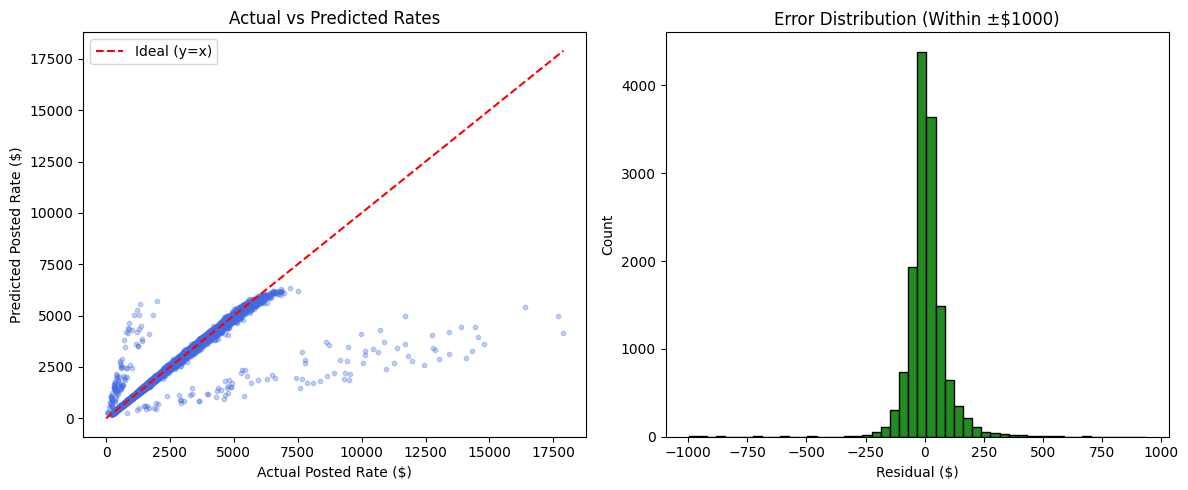

In [57]:
import matplotlib.pyplot as plt

residuals = y_test - cb_test_pred

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, cb_test_pred, alpha=0.3, s=10, color='royalblue')
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--', label='Ideal (y=x)')
plt.title("Actual vs Predicted Rates")
plt.xlabel("Actual Posted Rate ($)")
plt.ylabel("Predicted Posted Rate ($)")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(residuals[residuals.abs() < 1000], bins=50, color='forestgreen', edgecolor='black')
plt.title("Error Distribution (Within ±$1000)")
plt.xlabel("Residual ($)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [58]:
import joblib

# Save model and categorical feature list
final_model.save_model("catboost_freight_model.cbm")
joblib.dump(categorical_cols, "categorical_cols.pkl")
print(" Model and feature metadata successfully saved!")

 Model and feature metadata successfully saved!
